__References__
- https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_tutorial.html#Loading-Visium-and-scRNA-seq-reference-data

# Creating an virtual environment    
- conda create -n C2L python=3.9
- conda activate C2L
- conda install -c conda-forge scvi-tools=1.1.2 pyro-ppl pytorch ipykernel
- pip install "cell2location @ git+https://github.com/BayraktarLab/cell2location.git"  
-> select kernel : C2L

# Loading Visium and scRNA-seq ref data

In [1]:
import cell2location
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
from matplotlib import rcParams

rcParams["pdf.fonttype"] = 42  

/home/khyeonmin/micromamba/envs/C2L/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/khyeonmin/micromamba/envs/C2L/lib/python3.9/site-packages/lightning/fabric/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


First, let’s define where we save the results of our analysis:

In [2]:
import os

# define analysis results
results_folder = "./cell2location_results/"

# os.makedirs(results_folder, exist_ok=True)

# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f"{results_folder}/reference_signatures"
run_name = f"{results_folder}/cell2location_map"

First let’s read spatial Visium data from 10X Space Ranger output. Here we use lymph node data generated by 10X and presented in Kleshchevnikov et al (section 4, Fig 4). This dataset can be conveniently downloaded and imported using scanpy.

In [3]:
adata_vis = sc.datasets.visium_sge(sample_id="V1_Human_Lymph_Node")

# save first sample name in obs
adata_vis.obs['sample'] = list(adata_vis.uns['spatial'].keys())[0]

/home/khyeonmin/micromamba/envs/C2L/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/khyeonmin/micromamba/envs/C2L/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Here we rename genes to ENSEMBL ID for correct matching between single cell and spatial data - so you can ignore the scanpy suggestion to call `.var_names_make_unique`.

In [4]:
# save gene name in var
adata_vis.var['SYMBOL'] = adata_vis.var_names

# set gene_ids to the new index.
adata_vis.var.set_index('gene_ids', drop=True, inplace=True)

Mitochondia-encoded genes (gene names start with prefix mt- or MT-) are irrelevant for spatial mapping because their expression represents technical artifacts in the single cell and nucleus data rather than biological abundance of mitochondria.

In [5]:
# find mitochondria-encoded (MT) genes
adata_vis.var['MT_gene'] = [gene.startswith('MT-') for gene in adata_vis.var['SYMBOL']]

# remove MT genes for spatial mapping (keeping their counts in the object)
adata_vis.obsm['MT'] = adata_vis[:, adata_vis.var['MT_gene'].values].X.toarray()
adata_vis = adata_vis[:, ~adata_vis.var['MT_gene'].values]

Published scRNA-seq datasets of lymph nodes have typically lacked an adequate representation of germinal centre-associated immune cell populations due to age of patient donors. We, therefore, include scRNA-seq datasets spanning lymph nodes, spleen and tonsils in our single-cell reference to ensure that we captured the full diversity of immune cell states likely to exist in the spatial transcriptomic dataset.  

Here we download this dataset, import into anndata and change variable names to ENSEMBL gene identifiers.

In [6]:
# read data
adata_ref = sc.read(
    f'./data/sc.h5ad',
    backup_url='https://cell2location.cog.sanger.ac.uk/paper/integrated_lymphoid_organ_scrna/RegressionNBV4Torch_57covariates_73260cells_10237genes/sc.h5ad'
)

100%|██████████| 527M/527M [03:50<00:00, 2.40MB/s]   


Rename genes to ENSEMBL ID for correct matching between single cell and spatial data.

In [7]:
# save adata_ref index
adata_ref.var['SYMBOL'] = adata_ref.var.index

# rename 'GeneID-2' as necessary for your data
adata_ref.var.set_index('GeneID-2', drop=True, inplace=True)

# delete unnecessary raw slot (to be removed in a future version of the tutorial)
del adata_ref.raw

The default parameters `cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12` are a good starting point, however, you can increase the cut-off to exclude more genes. To preserve marker genes of rare cell types we recommend low `cell_count_cutoff=5`, however, `cell_percentage_cutoff2` and `nonz_mean_cutoff` can be increased to select between 8k-16k genes.

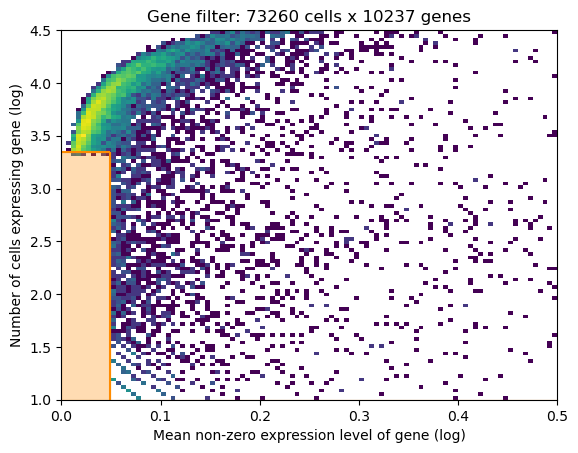

In [8]:
# 2D histogram
from cell2location.utils.filtering import filter_genes

selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)
adata_ref = adata_ref[:, selected].copy()

# Estimation of reference cell type signatures (NB regression)

The signatures are estimated from scRNA-seq data, accounting for batch effect, using a Negative binomial regression model.

## Preparing anndata

First, prepare anndata object for the regression model:

In [9]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(
    adata=adata_ref,
    # 10X reaction / sample / batch
    # batch_key='dataset',
    # cell type, covariate used for constructing signatures
    labels_key="Subset",
    # multiplicative technical effects (platform, 3' vs 5', donor effect)
    categorical_covariate_keys=['Method']
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [10]:
# create the regression model
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref)

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.1.2.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': 'Subset',
│   'categorical_covariate_keys': ['Method'],
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 73260 │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  34   │
│          n_vars          │ 10237 │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         ind_x          │           adata.obs['_indices']            │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃    Categories    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Subset'] │    B_Cycling     │          0          │
│                     │     B_GC_DZ      │          1          │
│                     │     B_GC_LZ      │          2          │
│                     │    B_GC_prePB    │          3          │
│                     │      B_IFN       │          4          │
│                     │   B_activated    │          5          │
│                     │      B_mem       │          6          │
│                     │     B_naive      │          7          │
│                     │     B_plasma     │          8          │
│                     │     B_preGC      │          9          │
│                     │     DC_CCR7+     │         10          │
│                     │     DC_cDC1      │         11          │
│                     │     DC_cDC2      │         12          │
│                     │      DC_pDC      │         13          │
│                     │       Endo       │         14          │
│                     │       FDC        │         15          │
│                     │       ILC        │         16          │
│                     │  Macrophages_M1  │         17          │
│                     │  Macrophages_M2  │         18          │
│                     │       Mast       │         19          │
│                     │    Monocytes     │         20          │
│                     │        NK        │         21          │
│                     │       NKT        │         22          │
│                     │      T_CD4+      │         23          │
│                     │    T_CD4+_TfH    │         24          │
│                     │  T_CD4+_TfH_GC   │         25          │
│                     │   T_CD4+_naive   │         26          │
│                     │  T_CD8+_CD161+   │         27          │
│                     │ T_CD8+_cytotoxic │         28          │
│                     │   T_CD8+_naive   │         29          │
│                     │     T_TIM3+      │         30          │
│                     │      T_TfR       │         31          │
│                     │      T_Treg      │         32          │
│                     │       VSMC       │         33          │
└─────────────────────┴──────────────────┴─────────────────────┘

          extra_categorical_covs State Registry           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Method'] │    3GEX    │          0          │
│                     │    5GEX    │          1          │
│                     │            │                     │
└─────────────────────┴────────────┴─────────────────────┘

## Training model (time-consuming step)

Now we train the model to estimate the reference cell type signatures.  
  
Note that to achieve convergence on your data (=to get stabilization of the loss) you may need to increase max_epochs=250 (See below).  
  
Also note that here we are using batch_size=2500 which is much larger than scvi-tools default and perform training on all cells in the data (train_size=1) - both parameters are defaults.  

If you want to use a GPU, then  

In [11]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

/home/khyeonmin/micromamba/envs/C2L/lib/python3.9/pty.py:85: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp39-cp39-linux_x86_64.whl (7.3 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp39-cp39-linux_x86_64.whl (3.4 MB)
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp39-cp39-linux_x86_64.whl (780.4 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cublas_cu12-12.1.3.1-py3-non

In [12]:
# training model with GPU
mod.train(max_epochs=250, accelerator="gpu")

# training model with CPU - takes a long time
# mod.train(max_epochs=250)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/khyeonmin/micromamba/envs/C2L/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/home/khyeonmin/micromamba/envs/C2L/lib/python3.9/site-packages/torch/cuda/__init__.py:230: UserWarning: 
NVIDIA GeForce RTX 5090 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5090 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(
You are using a CUDA device ('NVIDI

Epoch 250/250: 100%|██████████| 250/250 [15:38<00:00,  3.40s/it, v_num=1, elbo_train=2.96e+8]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|██████████| 250/250 [15:38<00:00,  3.75s/it, v_num=1, elbo_train=2.96e+8]


Determine if the model needs more training.

Here, we plot ELBO loss history during training, removing first 20 epochs from the plot. This plot should have a decreasing trend and level off by the end of training. If it is still decreasing, increase `max_epochs`.

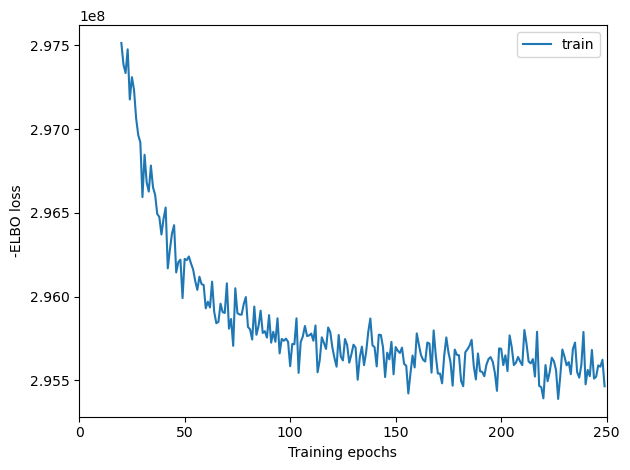

In [13]:
# plot ELBO loss history during training
mod.plot_history(20)

In this section, we export the estimated cell abundance (summary of the posterior distribution).

In [13]:
# export the estimated cell abundance
adata_ref = mod.export_posterior(adata_ref, sample_kwargs={"num_samples": 1000, "batch_size": 2500})

# Save model
mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
adata_file = f"{ref_run_name}/sc.h5ad"
adata_ref.write(adata_file)
adata_file

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Sampling local variables, batch:   0%|          | 0/30 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

'./cell2location_results//reference_signatures/sc.h5ad'

You can compute the 5%, 50% and 95% quantiles of the posterior distribution directly rather than using 1000 samples from the distribution (or any other quantiles). This speeds up application on large datasets and requires less memory - however, posterior mean and standard deviation cannot be computed this way.

In [14]:
adata_ref = mod.export_posterior(
    adata_ref,
    use_quantiles=True,
    sample_kwargs={"batch_size": 2500},
)

Examine QC plots.

Reconstruction accuracy to assess if there are any issues with inference. This 2D histogram plot should have most observations along a noisy diagonal.

The estimated expression signatures are distinct from mean expression in each cluster because of batch effects. For scRNA-seq datasets which do not suffer from batch effect (this dataset does), cluster average expression can be used instead of estimating signatures with a model. When this plot is very different from a diagonal plot (e.g. very low values on Y-axis, density everywhere) it indicates problems with signature estimation.

Sampling global variables, sample: 100%|██████████| 999/999 [00:08<00:00, 120.90it/s]


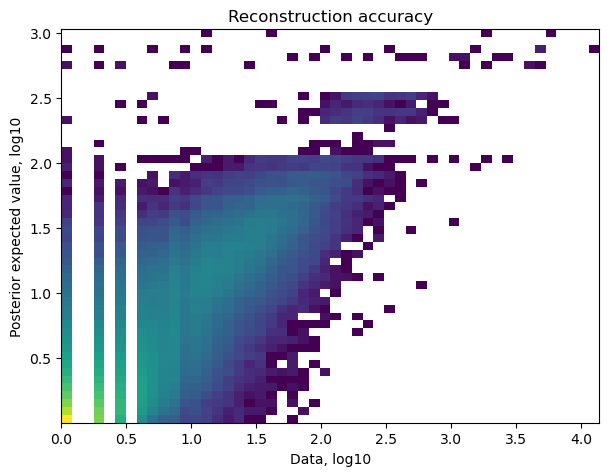

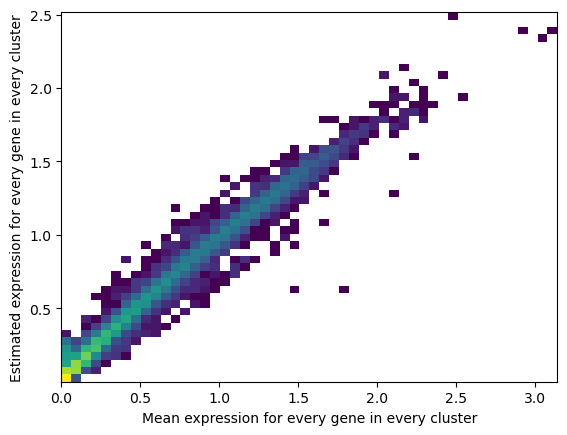

In [15]:
# QC plots
mod.export_posterior(adata_ref)
mod.plot_QC()

## Loading model and ouptut h5ad file

**The model training process takes a lot of time, so load the saved model and run next steps**

In [ ]:
# Loading model 
mod = cell2location.models.RegressionModel.load("/path/to/reference_signatures/model.pt", adata_ref)

# Loading output h5ad
adata_file = "/path/to/reference_signatures/sc.h5ad"
adata_ref = sc.read_h5ad(adata_file)

## Extracting reference cell types signatures as a pd.DataFrame

All parameters of the a Negative Binomial regression model are exported into reference anndata object, however for spatial mapping we just need the estimated expression of every gene in every cell type. Here we extract that from standard output:

In [16]:
# extract each gene expression level in each cluster
if "means_per_cluster_mu_fg" in adata_ref.varm.keys():
    inf_aver = adata_ref.varm["means_per_cluster_mu_fg"][
        [f"means_per_cluster_mu_fg_{i}" for i in adata_ref.uns["mod"]["factor_names"]]
    ].copy()
else:
    inf_aver = adata_ref.var[[f"means_per_cluster_mu_fg_{i}" for i in adata_ref.uns["mod"]["factor_names"]]].copy()
inf_aver.columns = adata_ref.uns["mod"]["factor_names"]
inf_aver.iloc[0:5, 0:5]

,B_Cycling,B_GC_DZ,B_GC_LZ,B_GC_prePB,B_IFN
GeneID-2,,,,,
ENSG00000188976,0.381006,0.236816,0.295545,0.357658,0.172109
ENSG00000188290,0.005058,0.000757,0.001002,0.057209,0.075615
ENSG00000187608,0.423897,0.286553,0.343877,0.628607,4.741733
ENSG00000186891,0.028511,0.001588,0.060923,0.068236,0.011602
ENSG00000186827,0.011140,0.000545,0.010100,0.032991,0.011651


# Cell2location: spatial mapping

Find shared genes and subset both anndata and reference signatures

In [17]:
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

In [18]:
# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key="sample")

Important
To use cell2location spatial mapping model, you need to specify 2 user-provided hyperparameters (`N_cells_per_location` and `detection_alpha`) - for detailed guidance on setting these hyperparameters and their impact see the flow diagram and the note.

Choosing hyperparameter ``N_cells_per_location``!

It is useful to adapt the expected cell abundance `N_cells_per_location` to every tissue. This value can be estimated from paired histology images and as described in the note above. Change the value presented in this tutorial (`N_cells_per_location=30`) to the value observed in your your tissue.

Choosing hyperparameter ``detection_alpha``!

To improve accuracy & sensitivity on datasets with large technical variability in RNA detection sensitivity within the slide/batch - you need to relax regularisation of per-location normalisation (use `detection_alpha=20`). High technical variability in RNA detection sensitivity is present in your sample when you observe the spatial distribution of total RNA count per location that doesn’t match expected cell numbers based on histological examination.

We initially opted for high regularisation (`detection_alpha=200`) as a default because the mouse brain & human lymph node datasets used in our paper have low technical effects and using high regularisation strenght improves consistencly between total estimated cell abundance per location and the nuclei count quantified from histology (Fig S8F in cell2location paper). However, in many collaborations, we see that Visium experiments on human tissues suffer from technical effects. This motivates the new default value of `detection_alpha=20` and the recommendation of testing both settings on your data (`detection_alpha=20` and `detection_alpha=200`).

In [19]:
# create and train the model
mod = cell2location.models.Cell2location(
    adata_vis,
    cell_state_df=inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=30,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20,
)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.1.2.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 4035  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 10217 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                       batch State Registry                        
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃     Categories      ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ V1_Human_Lymph_Node │          0          │
└─────────────────────┴─────────────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

## Training Cell2location (time-consuming step)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/khyeonmin/micromamba/envs/C2L/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/khyeonmin/micromamba/envs/C2L/lib/python3.9/site-packages/lightning/pytorch/loops/fit_loop.py:281: PossibleUserWarning: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 30000/30000: 100%|██████████| 30000/30000 [52:16<00:00, 10.17it/s, v_num=1, elbo_train=4.54e+7]  

`Trainer.fit` stopped: `max_epochs=30000` reached.


Epoch 30000/30000: 100%|██████████| 30000/30000 [52:16<00:00,  9.56it/s, v_num=1, elbo_train=4.54e+7]


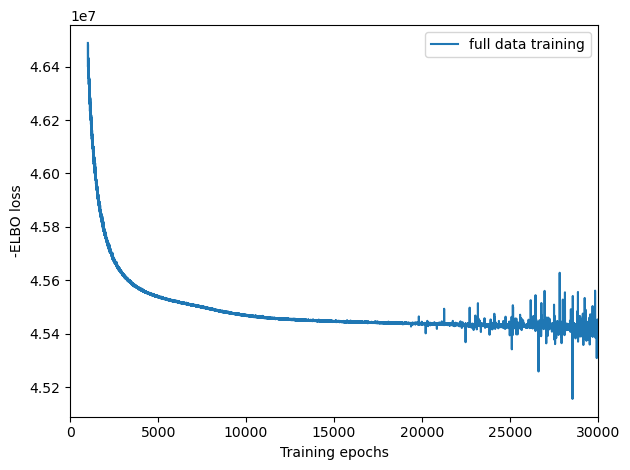

In [20]:
mod.train(
    max_epochs=30000,
    # train using full data (batch_size=None)
    batch_size=None,
    # use all data points in training because
    # we need to estimate cell abundance at all locations
    train_size=1,
    accelerator="gpu",
)

# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(1000)
plt.legend(labels=["full data training"])

Exporting estimated posterior distributions of cell abundance and saving results:

In [24]:
# export the estimated cell abundance (summary of the posterior distribution).
adata_vis  = mod.export_posterior(
    adata_vis , sample_kwargs={"num_samples": 1000, "batch_size": mod.adata.n_obs}
)

# Save model
mod.save(f"{run_name}", overwrite=True)

mod = cell2location.models.Cell2location.load(f"{run_name}", adata_vis)

# Save anndata object with results
adata_file = f"{run_name}/sp.h5ad"
adata_vis.write(adata_file)
adata_file

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Sampling local variables, batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File ./cell2location_results//cell2location_map/model.pt already downloaded                               


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/khyeonmin/micromamba/envs/cell2/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/khyeonmin/micromamba/envs/cell2/lib/python3.10/site-packages/lightn

Training:   0%|          | 0/30000 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1` reached.


'./cell2location_results//cell2location_map/sp.h5ad'

## Loading model and ouptut h5ad file

**The model training process takes a lot of time, so load the saved model and run next steps**

In [ ]:
# mod = cell2location.models.Cell2location.load(f"{run_name}", adata_vis)
mod = cell2location.models.Cell2location.load("/path/to/cell2location_map/model.pt", adata_vis)

# adata_file = f"{run_name}/sp.h5ad"
adata_file = "/path/to/cell2location_map/sp.h5ad"
adata_vis = sc.read_h5ad(adata_file)

Assessing mapping quality. Examine reconstruction accuracy to assess if there are any issues with mapping. The plot should be roughly diagonal, strong deviations will signal problems that need to be investigated.

Sampling global variables, sample: 100%|██████████| 999/999 [00:16<00:00, 59.55it/s]


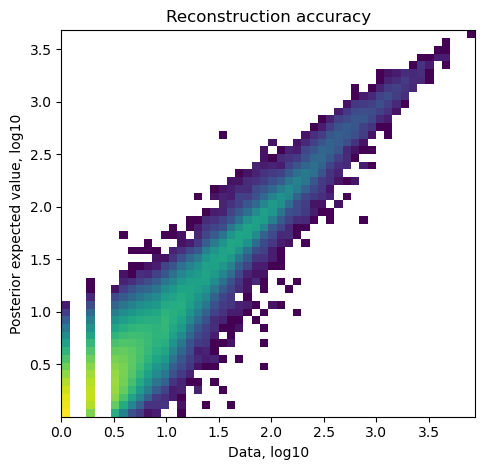

In [22]:
# mod.export_posterior(adata_vis)
# mod.plot_QC()

# Visualising cell abundance in spatial coordinates

In [23]:
print("adata_vis.obsm 키 목록:", list(adata_vis.obsm.keys()))

adata_vis.obsm 키 목록: ['spatial', 'MT', 'means_cell_abundance_w_sf', 'stds_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf']


In [24]:
# add 5% quantile, representing confident cell abundance, 'at least this amount is present',
# to adata.obs with nice names for plotting
adata_vis.obs[adata_vis.uns["mod"]["factor_names"]] = adata_vis.obsm["q05_cell_abundance_w_sf"]

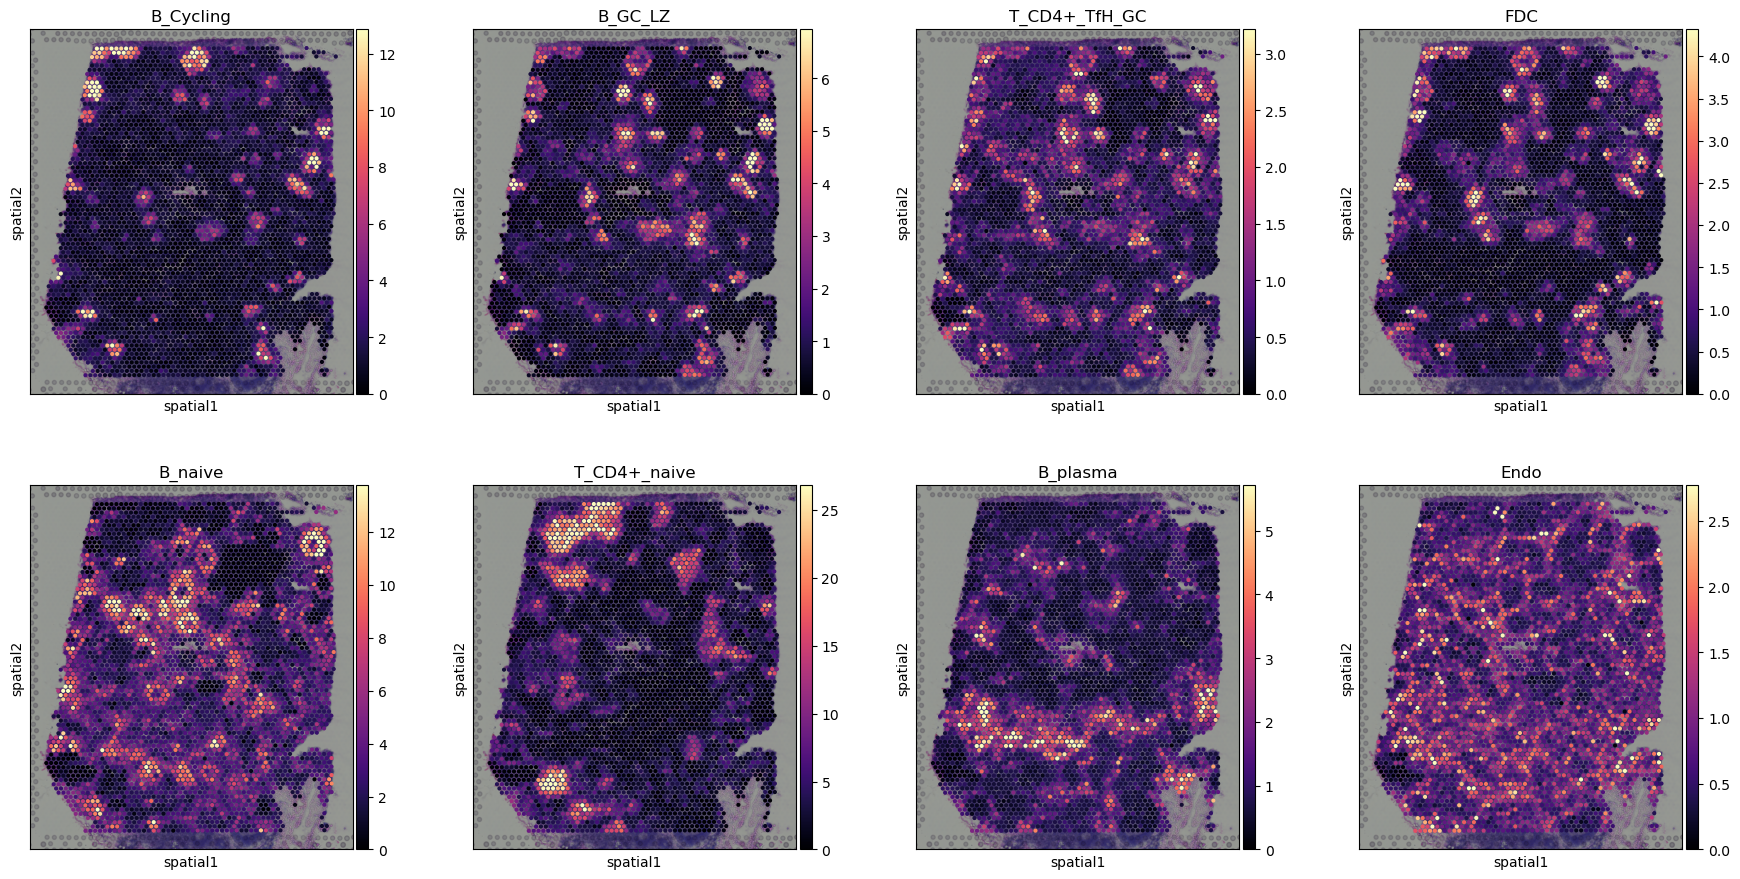

In [25]:
from cell2location.plt import plot_spatial

from cell2location.utils import select_slide
slide = select_slide(adata_vis, 'V1_Human_Lymph_Node')

with mpl.rc_context({'axes.facecolor':  'black',
                     'figure.figsize': [4.5, 5]}):

    sc.pl.spatial(slide, cmap='magma',
                  # show first 8 cell types
                  color=['B_Cycling', 'B_GC_LZ', 'T_CD4+_TfH_GC', 'FDC',
                         'B_naive', 'T_CD4+_naive', 'B_plasma', 'Endo'],
                  ncols=4, size=1.3,
                  img_key='hires',
                  # limit color scale at 99.2% quantile of cell abundance
                  vmin=0, vmax='p99.2'
                 )

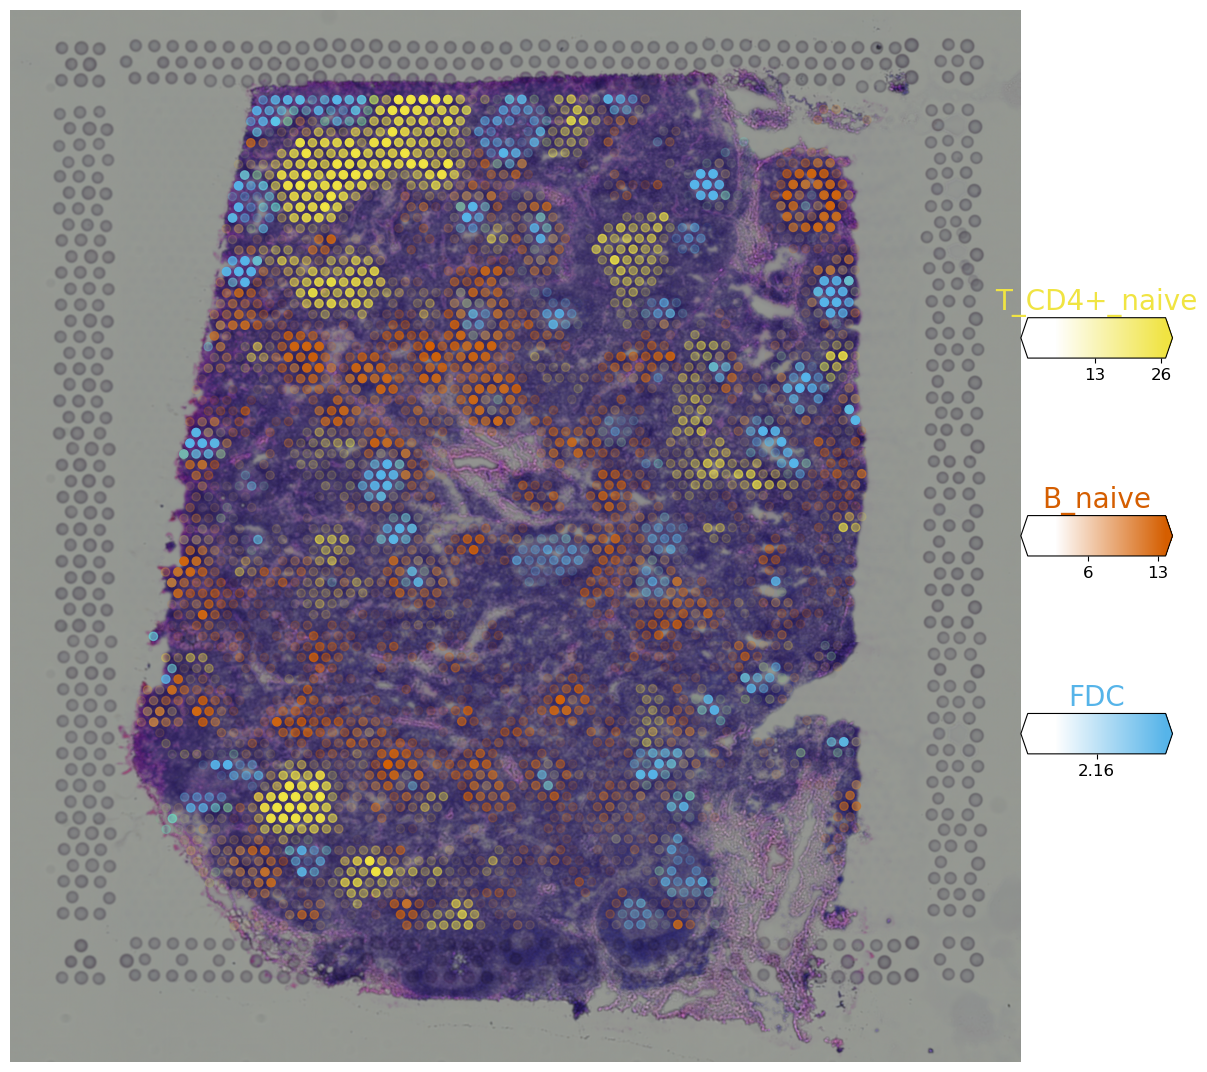

In [26]:
# Now we use cell2location plotter that allows showing multiple cell types in one panel
from cell2location.plt import plot_spatial

# select up to 6 clusters
clust_labels = ['T_CD4+_naive', 'B_naive', 'FDC']
clust_col = ['' + str(i) for i in clust_labels] # in case column names differ from labels

slide = select_slide(adata_vis, 'V1_Human_Lymph_Node')

with mpl.rc_context({'figure.figsize': (15, 15)}):
    fig = plot_spatial(
        adata=slide,
        # labels to show on a plot
        color=clust_col, labels=clust_labels,
        show_img=True,
        # 'fast' (white background) or 'dark_background'
        style='fast',
        # limit color scale at 99.2% quantile of cell abundance
        max_color_quantile=0.992,
        # size of locations (adjust depending on figure size)
        circle_diameter=6,
        colorbar_position='right'
    )

# Downstream analysis
### Identifying discrete tissue regions by Leiden clustering

In [32]:
!pip3 install igraph
!pip3 install leidenalg

/home/khyeonmin/micromamba/envs/C2L/lib/python3.9/pty.py:85: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


  Using cached leidenalg-0.10.2-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
Using cached leidenalg-0.10.2-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.0 MB)


In [33]:
# compute KNN using the cell2location output stored in adata.obsm
sc.pp.neighbors(adata_vis, use_rep='q05_cell_abundance_w_sf',
                n_neighbors = 15)

# Cluster spots into regions using scanpy
sc.tl.leiden(adata_vis, resolution=1.1)

# add region as categorical variable
adata_vis.obs["region_cluster"] = adata_vis.obs["leiden"].astype("category")

/tmp/ipykernel_3530012/23575634.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_vis, resolution=1.1)


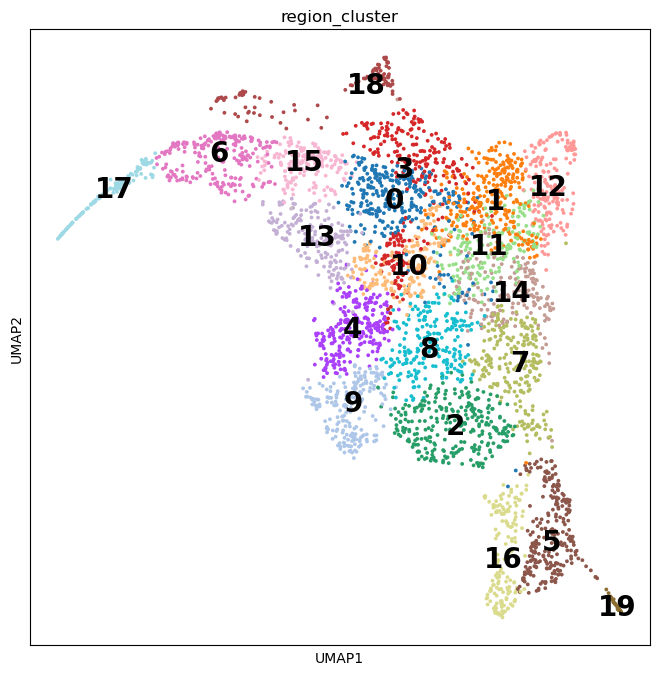

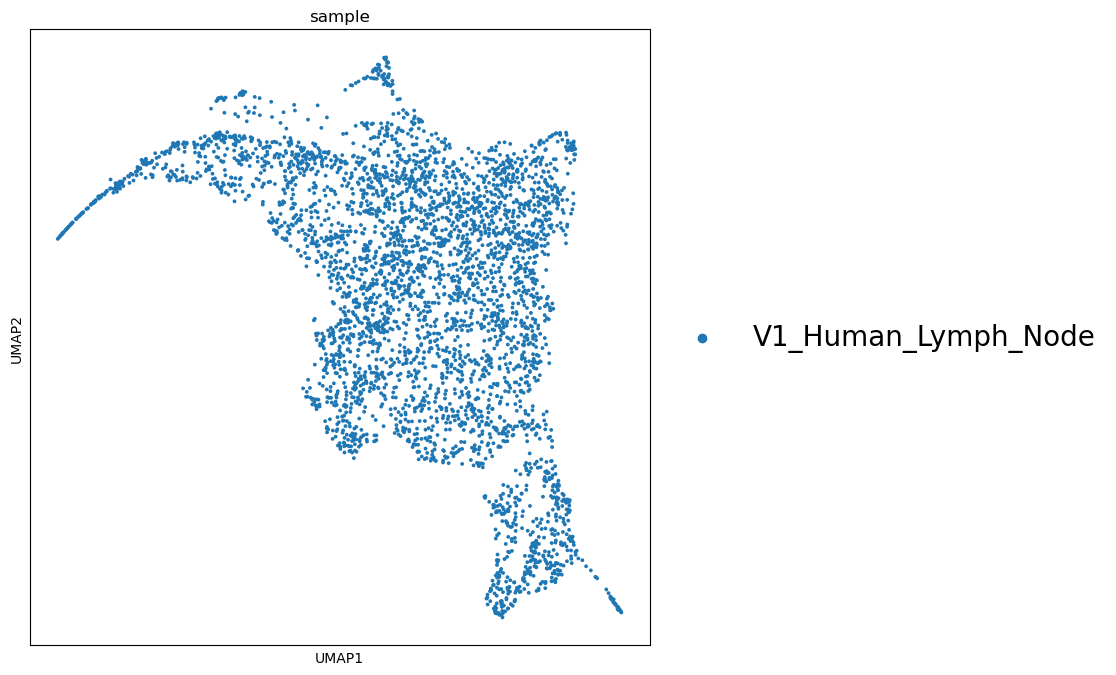

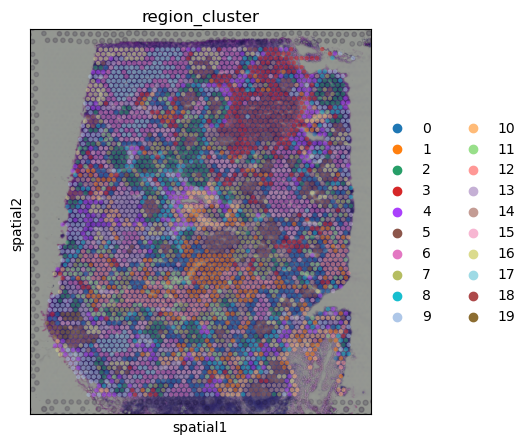

In [34]:
# compute UMAP using KNN graph based on the cell2location output
sc.tl.umap(adata_vis, min_dist = 0.3, spread = 1)

# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.pl.umap(adata_vis, color=['region_cluster'], size=30,
               color_map = 'RdPu', ncols = 2, legend_loc='on data',
               legend_fontsize=20)
    sc.pl.umap(adata_vis, color=['sample'], size=30,
               color_map = 'RdPu', ncols = 2,
               legend_fontsize=20)

# plot in spatial coordinates
with mpl.rc_context({'axes.facecolor':  'black',
                     'figure.figsize': [4.5, 5]}):
    sc.pl.spatial(adata_vis, color=['region_cluster'],
                  size=1.3, img_key='hires', alpha=0.5)

### Identifying cellular compartments / tissue zones using matrix factorisation (NMF)

In [35]:
from cell2location import run_colocation
res_dict, adata_vis = run_colocation(
    adata_vis,
    model_name='CoLocatedGroupsSklearnNMF',
    train_args={
      'n_fact': np.arange(11, 13), # IMPORTANT: use a wider range of the number of factors (5-30)
      'sample_name_col': 'sample', # columns in adata_vis.obs that identifies sample
      'n_restarts': 3 # number of training restarts
    },
    # the hyperparameters of NMF can be also adjusted:
    model_kwargs={'alpha': 0.01, 'init': 'random', "nmf_kwd_args": {"tol": 0.000001}},
    export_args={'path': f'{run_name}/CoLocatedComb/'}
)

### Analysis name: CoLocatedGroupsSklearnNMF_11combinations_4035locations_34factors
### Analysis name: CoLocatedGroupsSklearnNMF_12combinations_4035locations_34factors


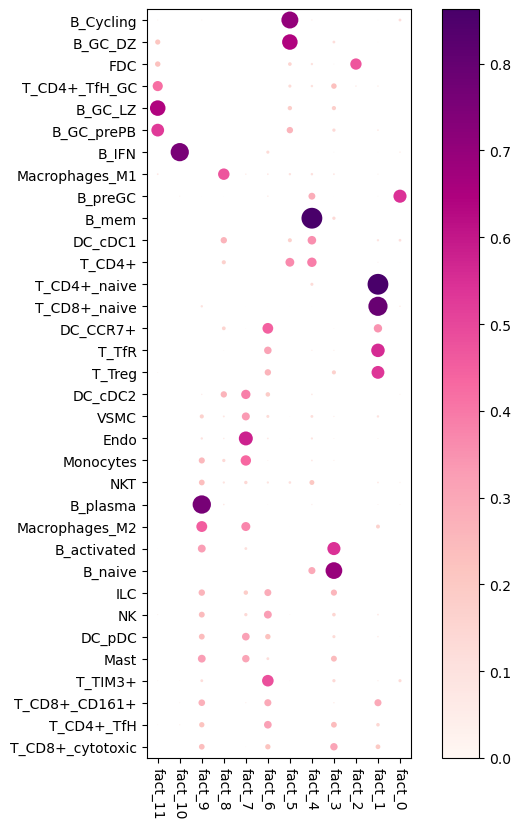

In [36]:
# Here we plot the NMF weights (Same as saved to `cell_type_fractions_heatmap`)
res_dict['n_fact12']['mod'].plot_cell_type_loadings()

### Estimate cell-type specific expression of every gene in the spatial data (needed for NCEM)

In [37]:
print(dir(mod))

['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_adata', '_adata_manager', '_check_if_trained', '_create_modalities_attr_dict', '_data_loader_cls', '_data_splitter_cls', '_export2adata', '_get_init_params', '_get_most_recent_anndata_manager', '_get_obs_plate_return_sites', '_get_obs_plate_sites', '_get_one_posterior_sample', '_get_posterior_samples', '_get_setup_method_args', '_get_user_attributes', '_make_data_loader', '_model_summary_string', '_module_init_on_train', '_optim_param', '_per_instance_manager_store', '_posterior_quantile', '_posterior_quantile_minibatch', '_posterior_samples_minibatch', '_register_manager_for_instance', '_setup_adata_manager_s

In [38]:
posterior_samples = mod.sample_posterior()
print(posterior_samples.keys())

Sampling global variables, sample: 100%|██████████| 999/999 [00:14<00:00, 70.83it/s]
dict_keys(['post_sample_means', 'post_sample_stds', 'post_sample_q05', 'post_sample_q95'])


In [39]:
q05_samples = posterior_samples['post_sample_q05']

# Compute expected expression per cell type
expected_dict = mod.module.model.compute_expected_per_cell_type(
    q05_samples, mod.adata_manager
)

# Add to anndata layers
for i, n in enumerate(mod.factor_names_):
    adata_vis.layers[n] = expected_dict['mu'][i]

# Save anndata object with results
adata_file = f"{run_name}/sp.h5ad"
adata_vis.write(adata_file)
adata_file

'./cell2location_results//cell2location_map/sp.h5ad'

In [40]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

def plot_genes_per_cell_type(slide, genes, ctypes):
    n_genes = len(genes)
    n_ctypes = len(ctypes)
    fig, axs = plt.subplots(
        nrows=n_genes, ncols=n_ctypes + 1, figsize=(4.5 * (n_ctypes + 1) + 2, 5 * n_genes + 1), squeeze=False
    )
    
    for j in range(n_genes):
        gene_condition = np.in1d(slide.var["SYMBOL"], genes[j])
        quantile_across_ct = np.array(
            [
                np.quantile(slide.layers[n][:, gene_condition].toarray(), 0.992)
                for n in slide.uns["mod"]["factor_names"]
            ]
        )
        quantile_across_ct = np.partition(quantile_across_ct.flatten(), -2)[-2]
        
        sc.pl.spatial(
            slide,
            cmap="magma",
            color=genes[j],
            gene_symbols="SYMBOL",
            ncols=4,
            size=1.3,
            img_key="hires",
            vmin=0,
            vmax="p99.2",
            ax=axs[j, 0],
            show=False,
        )

        for i in range(n_ctypes):
            sc.pl.spatial(
                slide,
                cmap="magma",
                color=genes[j],
                layer=ctypes[i],
                gene_symbols="SYMBOL",
                ncols=4,
                size=1.3,
                img_key="hires",
                vmin=0,
                vmax=quantile_across_ct,
                ax=axs[j, i + 1],
                show=False,  
            )
            axs[j, i + 1].set_title(f"{genes[j]} {ctypes[i]}")
    
    plt.show()
    return fig, axs


/tmp/ipykernel_3530012/375001806.py:13: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  gene_condition = np.in1d(slide.var["SYMBOL"], genes[j])


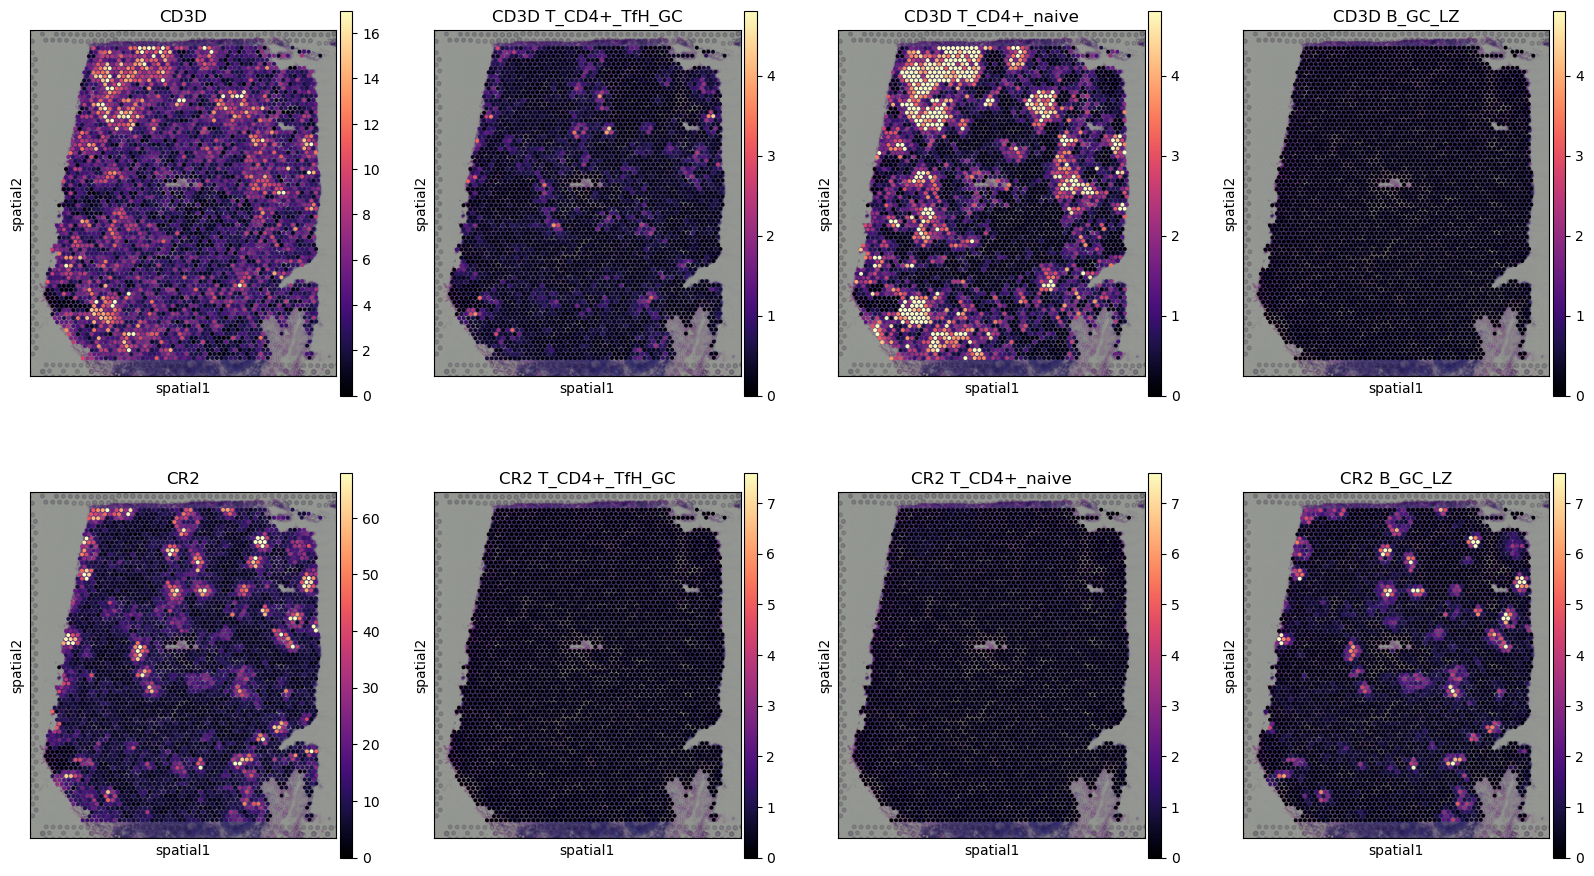

In [41]:
# list cell types and genes for plotting
ctypes = ['T_CD4+_TfH_GC', 'T_CD4+_naive', 'B_GC_LZ']
genes = ['CD3D', 'CR2']

with mpl.rc_context({'axes.facecolor':  'black'}):
    # select one slide
    slide = select_slide(adata_vis, 'V1_Human_Lymph_Node')

    # from tutorial_utils import plot_genes_per_cell_type
    plot_genes_per_cell_type(slide, genes, ctypes)